# E-Commerce Sales EDA — UK Online Retail (2009–2011)
**Dataset:** UCI Online Retail II | **Tool:** Python | **Period:** Dec 2009–Dec 2011

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Step 1 — Import & Understand the Data
Loading 1,067,371 rows across 8 columns from two Excel sheets combined.

In [ ]:
df_01 = pd.read_excel(r'C:\Users\Sundas Memon\Desktop\Projects for Portfolio\Project-3 EDA/online_retail_II.xlsx' , sheet_name='Year 2009-2010')
df_02 = pd.read_excel(r'C:\Users\Sundas Memon\Desktop\Projects for Portfolio\Project-3 EDA/online_retail_II.xlsx' , sheet_name='Year 2010-2011')
df = pd.concat([df_01, df_02], ignore_index=True)

In [6]:
print(df.shape)
df.info()

(1067371, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


In [7]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [8]:
print("=== BUSINESS CONTEXT ===")
print(f"Unique invoices:  {df['Invoice'].nunique():,}")
print(f"Unique customers: {df['Customer ID'].nunique():,}")
print(f"Unique products:  {df['StockCode'].nunique():,}")
print(f"Countries:        {df['Country'].nunique()}")
print(f"\nDate range: {df['InvoiceDate'].min()} → {df['InvoiceDate'].max()}")
print(f"\nTop 10 countries:\n{df['Country'].value_counts().head(10)}")

print("\n=== RED FLAGS TO INVESTIGATE IN STEP 3 ===")
print(f"Missing Customer IDs: {df['Customer ID'].isnull().sum():,}")
print(f"Missing Descriptions: {df['Description'].isnull().sum():,}")
print(f"Negative quantities:  {(df['Quantity'] < 0).sum():,}")
print(f"Zero prices:          {(df['Price'] == 0).sum():,}")
print(f"Cancellations (C):    {df['Invoice'].str.startswith('C', na=False).sum():,}")

df['Revenue'] = df['Quantity'] * df['Price']
print(f"\nTotal raw revenue: £{df['Revenue'].sum():,.2f}")

=== BUSINESS CONTEXT ===
Unique invoices:  53,628
Unique customers: 5,942
Unique products:  5,305
Countries:        43

Date range: 2009-12-01 07:45:00 → 2011-12-09 12:50:00

Top 10 countries:
Country
United Kingdom    981330
EIRE               17866
Germany            17624
France             14330
Netherlands         5140
Spain               3811
Switzerland         3189
Belgium             3123
Portugal            2620
Australia           1913
Name: count, dtype: int64

=== RED FLAGS TO INVESTIGATE IN STEP 3 ===
Missing Customer IDs: 243,007
Missing Descriptions: 4,382
Negative quantities:  22,950
Zero prices:          6,202
Cancellations (C):    19,494

Total raw revenue: £19,287,250.57


## Step 2 — Analyze Structure & Handle Nulls

Two columns have missing values: Customer ID (22.8%) and Description (0.41%). 
Customer IDs are guest checkouts kept for revenue analysis. 
Descriptions filled from matching StockCode where possible.

In [9]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
Revenue             0
dtype: int64

In [10]:
# Confirm they still have revenue
guest = df[df['Customer ID'].isnull()]
print(f"Guest checkout revenue: £{(guest['Quantity'] * guest['Price']).sum():,.2f}")

Guest checkout revenue: £2,638,958.18


In [11]:
# Fill missing descriptions from same StockCode
desc_map = df.dropna(subset=['Description']).groupby('StockCode')['Description'].agg(lambda x: x.mode()[0])
df['Description'] = df['Description'].fillna(df['StockCode'].map(desc_map))

# Confirm
print(f"Remaining nulls after fill: {df['Description'].isnull().sum()}")

Remaining nulls after fill: 363


In [12]:
print("=== NULL STATUS AFTER FIXES ===")
print(df.isnull().sum())

print(f"\nRows with no Customer ID (kept): {df['Customer ID'].isnull().sum():,}")
print(f"Unfillable descriptions (kept):  {df['Description'].isnull().sum():,}")
print(f"All other columns null:          {df.drop(columns=['Customer ID','Description']).isnull().sum().sum()}")

=== NULL STATUS AFTER FIXES ===
Invoice             0
StockCode           0
Description       363
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
Revenue             0
dtype: int64

Rows with no Customer ID (kept): 243,007
Unfillable descriptions (kept):  363
All other columns null:          0


## Step 3 — Data Cleaning
Removed duplicates, isolated cancellations and returns, removed zero prices.
36,961 duplicate rows removed. 25,123 returns saved separately in df_returns.
Final clean dataset: 1,007,913 rows | £20,476,260 revenue.

In [13]:
print("=== DUPLICATES ===")
print(f"Duplicate rows: {df.duplicated().sum():,}")
# Drop them
df = df.drop_duplicates()
print(f"Rows after dropping duplicates: {len(df):,}")


=== DUPLICATES ===
Duplicate rows: 34,335
Rows after dropping duplicates: 1,033,036


In [14]:
# Cancellations = Invoice starts with 'C'
cancellations = df[df['Invoice'].str.startswith('C', na=False)]
print(f"=== CANCELLATIONS ===")
print(f"Cancellation rows:    {len(cancellations):,}")
print(f"Cancellation revenue: £{(cancellations['Quantity'] * cancellations['Price']).sum():,.2f}")

# Negative quantities (returns not caught by C prefix)
negatives = df[df['Quantity'] < 0]
print(f"\n=== NEGATIVE QUANTITIES ===")
print(f"Negative quantity rows: {len(negatives):,}")

# How much overlap is there between the two?
overlap = df[df['Invoice'].str.startswith('C', na=False) & (df['Quantity'] < 0)]
print(f"Rows that are BOTH (C prefix AND negative): {len(overlap):,}")

# Keep a returns dataframe for analysis later
df_returns = df[df['Invoice'].str.startswith('C', na=False) | (df['Quantity'] < 0)].copy()
print(f"\nTotal returns/cancellations saved: {len(df_returns):,}")

# Clean dataframe = remove all of them
df_clean = df[~df['Invoice'].str.startswith('C', na=False) & (df['Quantity'] > 0)].copy()
print(f"Clean rows remaining: {len(df_clean):,}")

=== CANCELLATIONS ===
Cancellation rows:    19,104
Cancellation revenue: £-1,462,050.61

=== NEGATIVE QUANTITIES ===
Negative quantity rows: 22,496
Rows that are BOTH (C prefix AND negative): 19,103

Total returns/cancellations saved: 22,497
Clean rows remaining: 1,010,539


In [15]:
print("=== ZERO PRICE ROWS ===")
zero_price = df_clean[df_clean['Price'] == 0]
print(f"Zero price rows: {len(zero_price):,}")
print(f"\nStockCodes with zero price:")
print(zero_price['StockCode'].value_counts().head(10))
print(f"\nDescriptions with zero price:")
print(zero_price['Description'].value_counts().head(10))

=== ZERO PRICE ROWS ===
Zero price rows: 2,621

StockCodes with zero price:
StockCode
79321     15
21116     14
22501     14
23084     13
46000M    12
35965     11
22734     11
46000S    10
22502     10
84990      9
Name: count, dtype: int64

Descriptions with zero price:
Description
check                           39
found                           28
CHILLI LIGHTS                   15
adjustment                      14
OWL DOORSTOP                    14
PICNIC BASKET WICKER LARGE      12
POLYESTER FILLER PAD 45x45cm    12
POLYESTER FILLER PAD 40x40cm    10
?                                9
HEART OF WICKER SMALL            9
Name: count, dtype: int64


In [16]:
# Remove zero price rows from clean data
df_clean = df_clean[df_clean['Price'] > 0].copy()
print(f"Rows after removing zero prices: {len(df_clean):,}")

Rows after removing zero prices: 1,007,913


In [17]:
# Fill missing descriptions
desc_map = df.dropna(subset=['Description']).groupby('StockCode')['Description'].agg(lambda x: x.mode()[0])
df['Description'] = df['Description'].fillna(df['StockCode'].map(desc_map))

# Remove duplicates
df = df.drop_duplicates()

# Isolate ALL non-sale rows into returns
df_returns = df[
    df['Invoice'].str.startswith('C', na=False) |
    (df['Quantity'] <= 0) |
    (df['Price'] <= 0)
].copy()

# Clean = only genuine positive sales
df_clean = df[
    ~df['Invoice'].str.startswith('C', na=False) &
    (df['Quantity'] > 0) &
    (df['Price'] > 0)
].copy()

df_clean['Revenue'] = df_clean['Quantity'] * df_clean['Price']
df_returns['Revenue'] = df_returns['Quantity'] * df_returns['Price']

print("=== STEP 3 COMPLETE ===")
print(f"Clean rows:        {len(df_clean):,}")
print(f"Return rows saved: {len(df_returns):,}")
print(f"Clean revenue:     £{df_clean['Revenue'].sum():,.2f}")
print(f"Negative qty:      {(df_clean['Quantity'] < 0).sum()}")
print(f"Negative price:    {(df_clean['Price'] < 0).sum()}")
print(f"Zero price:        {(df_clean['Price'] == 0).sum()}")
print(f"Cancellations:     {df_clean['Invoice'].str.startswith('C', na=False).sum()}")

=== STEP 3 COMPLETE ===
Clean rows:        1,007,913
Return rows saved: 25,123
Clean revenue:     £20,476,260.45
Negative qty:      0
Negative price:    0
Zero price:        0
Cancellations:     0


## Step 4 — Descriptive Statistics

Summarising revenue, quantity, price, customer and product data 
using mean, median, mode, standard deviation and distribution ranges.

In [18]:
print("=== DESCRIPTIVE STATISTICS ===")
print(df_clean[['Quantity', 'Price', 'Revenue']].describe().round(2))

=== DESCRIPTIVE STATISTICS ===
         Quantity       Price     Revenue
count  1007913.00  1007913.00  1007913.00
mean        11.12        4.07       20.32
std        128.47       50.43      205.72
min          1.00        0.00        0.00
25%          1.00        1.25        4.13
50%          4.00        2.10       10.08
75%         12.00        4.13       17.70
max      80995.00    25111.09   168469.60


In [19]:
print("=== REVENUE STATISTICS ===")
print(f"Total revenue:        £{df_clean['Revenue'].sum():,.2f}")
print(f"Average order line:   £{df_clean['Revenue'].mean():,.2f}")
print(f"Median order line:    £{df_clean['Revenue'].median():,.2f}")
print(f"Std deviation:        £{df_clean['Revenue'].std():,.2f}")
print(f"Highest single line:  £{df_clean['Revenue'].max():,.2f}")
print(f"Lowest single line:   £{df_clean['Revenue'].min():,.2f}")

# Revenue per invoice (true order value)
order_revenue = df_clean.groupby('Invoice')['Revenue'].sum()
print(f"\n=== PER INVOICE (ORDER LEVEL) ===")
print(f"Average order value:  £{order_revenue.mean():,.2f}")
print(f"Median order value:   £{order_revenue.median():,.2f}")
print(f"Highest order:        £{order_revenue.max():,.2f}")
print(f"Lowest order:         £{order_revenue.min():,.2f}")

=== REVENUE STATISTICS ===
Total revenue:        £20,476,260.45
Average order line:   £20.32
Median order line:    £10.08
Std deviation:        £205.72
Highest single line:  £168,469.60
Lowest single line:   £0.00

=== PER INVOICE (ORDER LEVEL) ===
Average order value:  £510.92
Median order value:   £302.22
Highest order:        £168,469.60
Lowest order:         £0.19


In [20]:
print("=== QUANTITY STATISTICS ===")
print(f"Average qty per line: {df_clean['Quantity'].mean():,.2f}")
print(f"Median qty per line:  {df_clean['Quantity'].median():,.2f}")
print(f"Most common qty:      {df_clean['Quantity'].mode()[0]}")
print(f"Max qty single line:  {df_clean['Quantity'].max():,}")
print(f"Min qty single line:  {df_clean['Quantity'].min():,}")

# Quantity brackets — how do customers order?
bins = [0, 10, 50, 100, 500, 1000, df_clean['Quantity'].max()]
labels = ['1-10', '11-50', '51-100', '101-500', '501-1000', '1000+']
df_clean['Qty_Bracket'] = pd.cut(df_clean['Quantity'], bins=bins, labels=labels)
print(f"\n=== ORDER SIZE BREAKDOWN ===")
print(df_clean['Qty_Bracket'].value_counts().sort_index())

=== QUANTITY STATISTICS ===
Average qty per line: 11.12
Median qty per line:  4.00
Most common qty:      1
Max qty single line:  80,995
Min qty single line:  1

=== ORDER SIZE BREAKDOWN ===
Qty_Bracket
1-10        752892
11-50       231062
51-100       13808
101-500       9199
501-1000       651
1000+          301
Name: count, dtype: int64


In [21]:
print("=== PRICE STATISTICS ===")
print(f"Average unit price:   £{df_clean['Price'].mean():,.2f}")
print(f"Median unit price:    £{df_clean['Price'].median():,.2f}")
print(f"Most common price:    £{df_clean['Price'].mode()[0]:,.2f}")
print(f"Most expensive item:  £{df_clean['Price'].max():,.2f}")
print(f"Cheapest item:        £{df_clean['Price'].min():,.2f}")

# Price brackets
price_bins = [0, 1, 5, 10, 20, 50, df_clean['Price'].max()]
price_labels = ['under £1', '£1-5', '£5-10', '£10-20', '£20-50', '£50+']
df_clean['Price_Bracket'] = pd.cut(df_clean['Price'], bins=price_bins, labels=price_labels)
print(f"\n=== PRICE RANGE BREAKDOWN ===")
print(df_clean['Price_Bracket'].value_counts().sort_index())

=== PRICE STATISTICS ===
Average unit price:   £4.07
Median unit price:    £2.10
Most common price:    £1.25
Most expensive item:  £25,111.09
Cheapest item:        £0.00

=== PRICE RANGE BREAKDOWN ===
Price_Bracket
under £1    199613
£1-5        632945
£5-10       127383
£10-20       39725
£20-50        6323
£50+          1924
Name: count, dtype: int64


In [22]:
print("=== CUSTOMER STATISTICS ===")
customer_orders = df_clean.groupby('Customer ID')['Invoice'].nunique()
customer_revenue = df_clean.groupby('Customer ID')['Revenue'].sum()

print(f"Total customers:          {df_clean['Customer ID'].nunique():,}")
print(f"Avg orders per customer:  {customer_orders.mean():,.2f}")
print(f"Median orders/customer:   {customer_orders.median():,.2f}")
print(f"Most orders by 1 customer:{customer_orders.max():,}")
print(f"Avg revenue per customer: £{customer_revenue.mean():,.2f}")
print(f"Median revenue/customer:  £{customer_revenue.median():,.2f}")
print(f"Highest spending customer:£{customer_revenue.max():,.2f}")

print(f"\n=== PRODUCT STATISTICS ===")
product_revenue = df_clean.groupby('Description')['Revenue'].sum()
product_qty = df_clean.groupby('Description')['Quantity'].sum()

print(f"Total unique products:    {df_clean['Description'].nunique():,}")
print(f"Top 5 by revenue:")
print(product_revenue.sort_values(ascending=False).head())
print(f"\nTop 5 by quantity sold:")
print(product_qty.sort_values(ascending=False).head())

=== CUSTOMER STATISTICS ===
Total customers:          5,878
Avg orders per customer:  6.29
Median orders/customer:   3.00
Most orders by 1 customer:398
Avg revenue per customer: £2,955.90
Median revenue/customer:  £867.74
Highest spending customer:£580,987.04

=== PRODUCT STATISTICS ===
Total unique products:    5,399
Top 5 by revenue:
Description
Manual                                339241.29
REGENCY CAKESTAND 3 TIER              330590.32
DOTCOM POSTAGE                        309854.11
WHITE HANGING HEART T-LIGHT HOLDER    260990.22
PAPER CRAFT , LITTLE BIRDIE           168469.60
Name: Revenue, dtype: float64

Top 5 by quantity sold:
Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     106139
WHITE HANGING HEART T-LIGHT HOLDER     94658
PAPER CRAFT , LITTLE BIRDIE            80995
ASSORTED COLOUR BIRD ORNAMENT          80082
MEDIUM CERAMIC TOP STORAGE JAR         78033
Name: Quantity, dtype: int64


In [23]:
# Remove internal non-product entries for product analysis
non_products = ['Manual', 'DOTCOM POSTAGE', 'POSTAGE', 'Adjust bad debt']
df_products = df_clean[~df_clean['Description'].isin(non_products)].copy()

print(f"Rows for product analysis: {len(df_products):,}")
print(f"Revenue after removing non-products: £{df_products['Revenue'].sum():,.2f}")

Rows for product analysis: 1,003,795
Revenue after removing non-products: £19,690,420.57


 ## Step 5 — Distributions

* Revenue Distribution

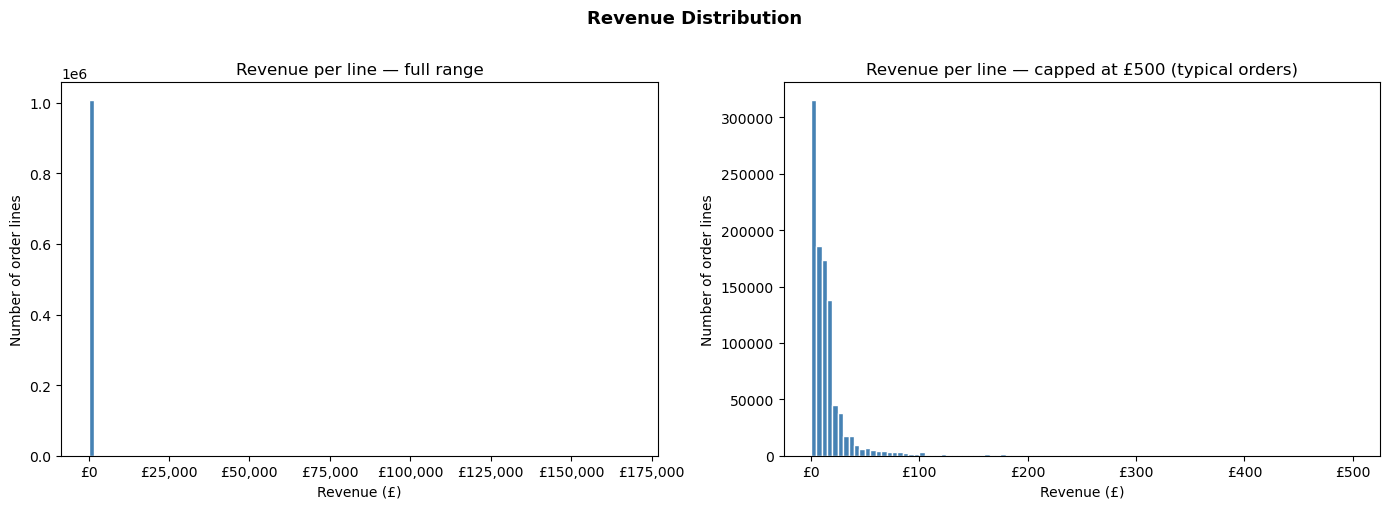

Orders under £500: 1,005,657 (99.8%)
Orders over £500:  2,256 (0.2%)


In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left — full distribution (will show extreme skew)
axes[0].hist(df_clean['Revenue'], bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Revenue per line — full range')
axes[0].set_xlabel('Revenue (£)')
axes[0].set_ylabel('Number of order lines')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))

# Right — capped at £500 to see typical orders clearly
axes[1].hist(df_clean[df_clean['Revenue'] <= 500]['Revenue'], 
             bins=100, color='steelblue', edgecolor='white')
axes[1].set_title('Revenue per line — capped at £500 (typical orders)')
axes[1].set_xlabel('Revenue (£)')
axes[1].set_ylabel('Number of order lines')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))

plt.suptitle('Revenue Distribution', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('revenue_distribution.png', bbox_inches='tight')
plt.show()
print(f"Orders under £500: {(df_clean['Revenue'] <= 500).sum():,} ({(df_clean['Revenue'] <= 500).mean()*100:.1f}%)")
print(f"Orders over £500:  {(df_clean['Revenue'] > 500).sum():,} ({(df_clean['Revenue'] > 500).mean()*100:.1f}%)")

* Quantity Distribution

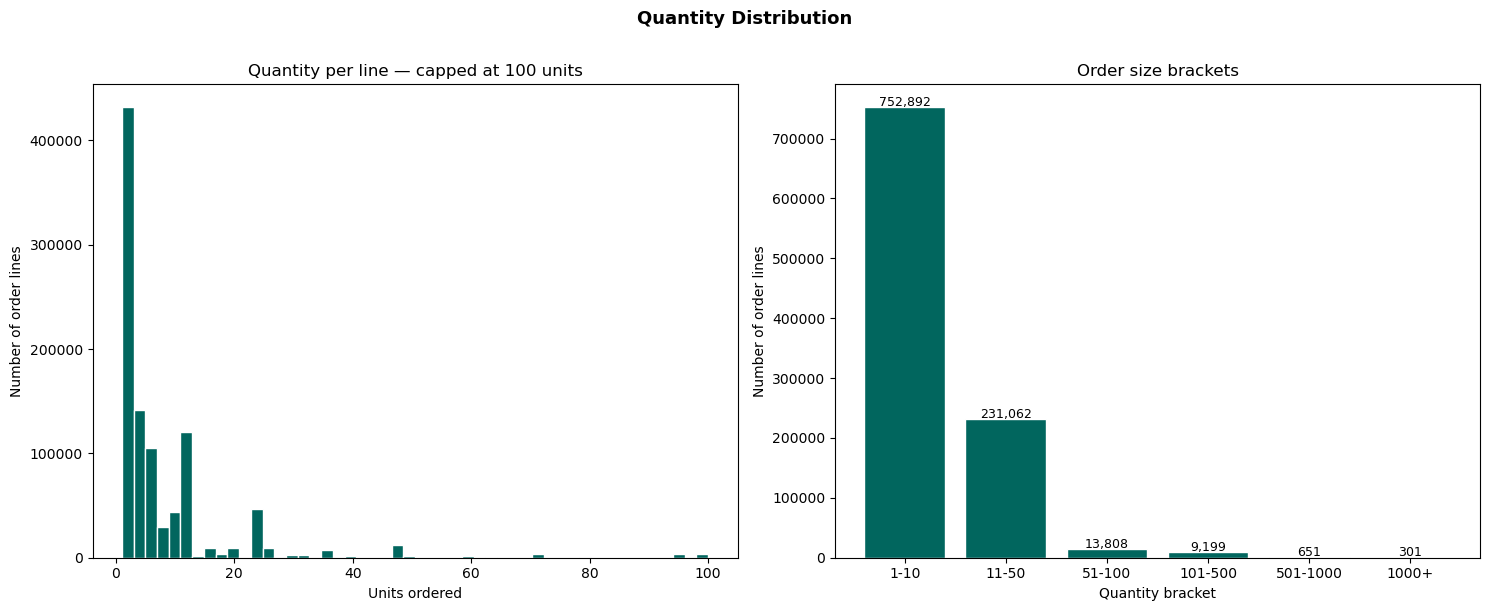

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left — capped at 100 units to see typical
axes[0].hist(df_clean[df_clean['Quantity'] <= 100]['Quantity'],
             bins=50, color='#01665e', edgecolor='white') # Using the palette's deep teal
axes[0].set_title('Quantity per line — capped at 100 units')
axes[0].set_xlabel('Units ordered')
axes[0].set_ylabel('Number of order lines')

# Right — order size bracket bar chart
bracket_counts = df_clean['Qty_Bracket'].value_counts().sort_index()
axes[1].bar(bracket_counts.index, bracket_counts.values, color='#01665e', edgecolor='white')
axes[1].set_title('Order size brackets')
axes[1].set_xlabel('Quantity bracket')
axes[1].set_ylabel('Number of order lines')
for i, v in enumerate(bracket_counts.values):
    axes[1].text(i, v + 2000, f'{v:,}', ha='center', fontsize=9)

plt.suptitle('Quantity Distribution', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('quantity_distribution.png', bbox_inches='tight')
plt.show()

- Price Distribution

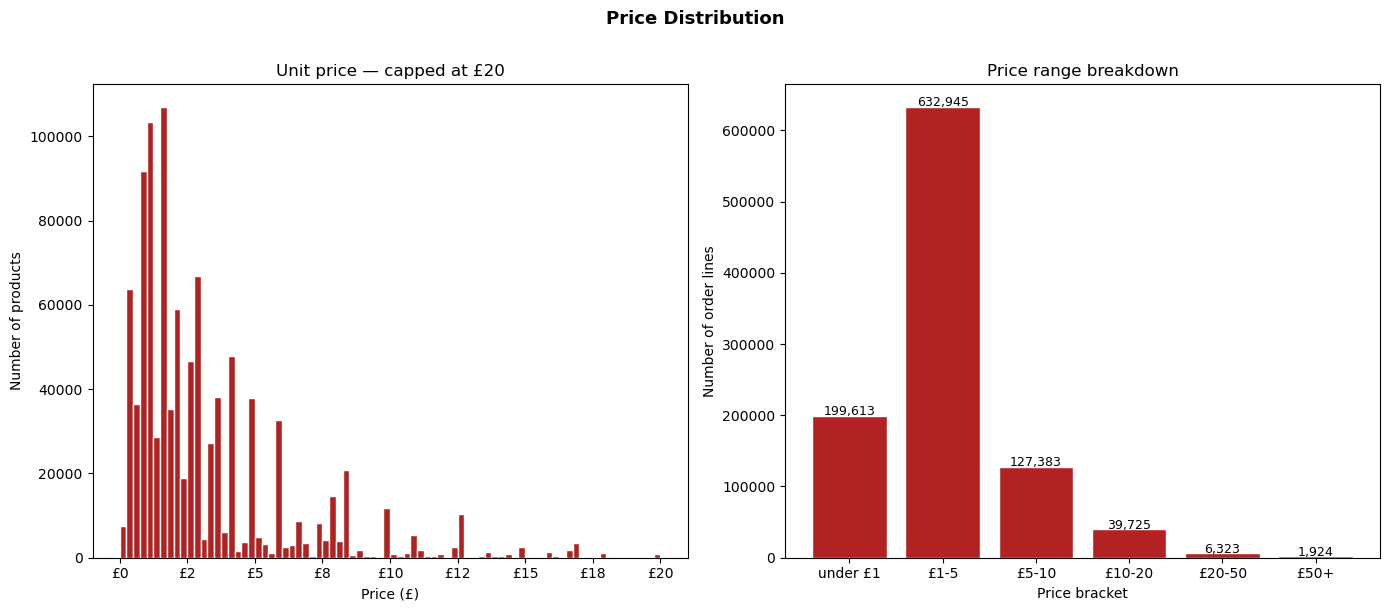

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left — capped at £20 to see typical prices
axes[0].hist(df_clean[df_clean['Price'] <= 20]['Price'],
             bins=80, color='firebrick', edgecolor='white')
axes[0].set_title('Unit price — capped at £20')
axes[0].set_xlabel('Price (£)')
axes[0].set_ylabel('Number of products')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:.0f}'))

# Right — price bracket bar chart
price_counts = df_clean['Price_Bracket'].value_counts().sort_index()
axes[1].bar(price_counts.index, price_counts.values, color='firebrick', edgecolor='white')
axes[1].set_title('Price range breakdown')
axes[1].set_xlabel('Price bracket')
axes[1].set_ylabel('Number of order lines')
for i, v in enumerate(price_counts.values):
    axes[1].text(i, v + 1000, f'{v:,}', ha='center', fontsize=9)

plt.suptitle('Price Distribution', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('price_distribution.png', bbox_inches='tight')
plt.show()

- Product Performamce

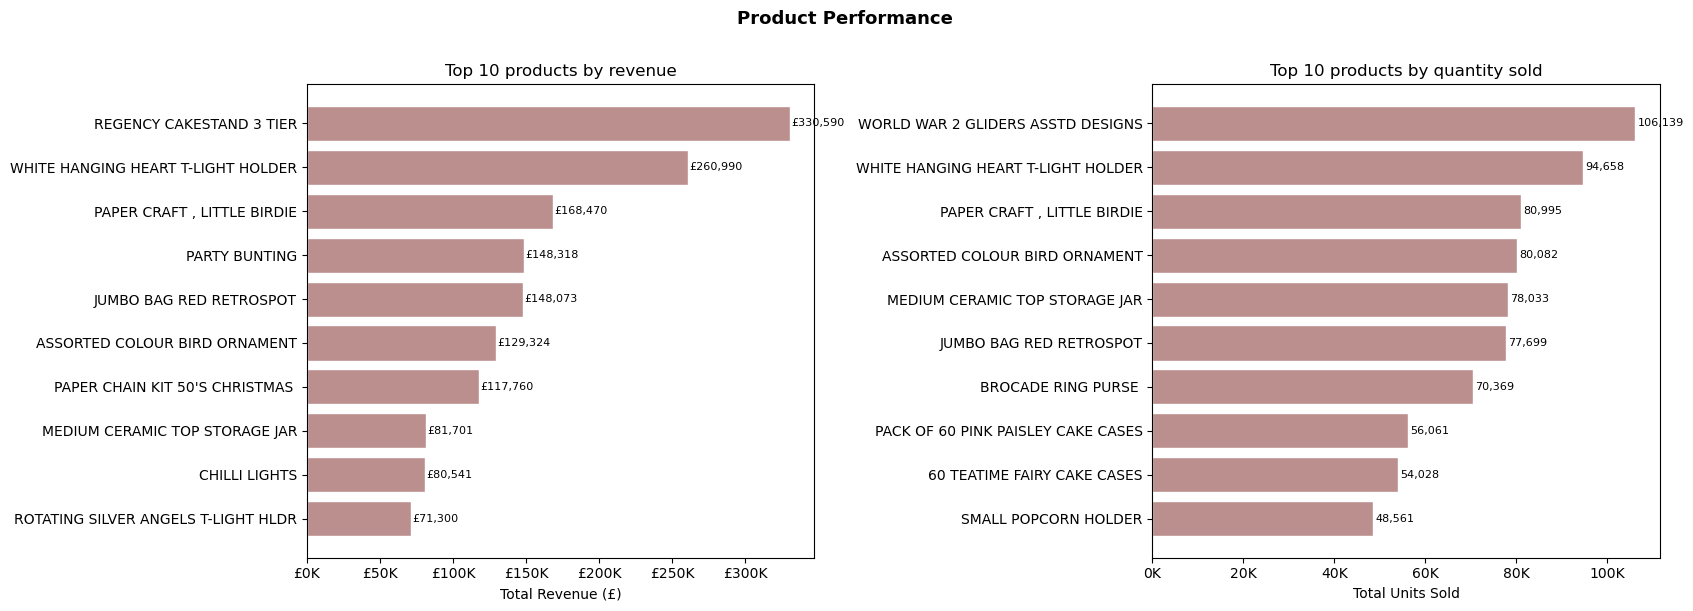

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# Top 10 by revenue — exclude non-products
top_rev = (df_products.groupby('Description')['Revenue']
           .sum().sort_values(ascending=False).head(10))

axes[0].barh(top_rev.index[::-1], top_rev.values[::-1], color='rosybrown', edgecolor='white')
axes[0].set_title('Top 10 products by revenue')
axes[0].set_xlabel('Total Revenue (£)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
for i, v in enumerate(top_rev.values[::-1]):
    axes[0].text(v + 1000, i, f'£{v:,.0f}', va='center', fontsize=8)

# Top 10 by quantity
top_qty = (df_products.groupby('Description')['Quantity']
           .sum().sort_values(ascending=False).head(10))

axes[1].barh(top_qty.index[::-1], top_qty.values[::-1], color='rosybrown', edgecolor='white')
axes[1].set_title('Top 10 products by quantity sold')
axes[1].set_xlabel('Total Units Sold')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
for i, v in enumerate(top_qty.values[::-1]):
    axes[1].text(v + 500, i, f'{v:,}', va='center', fontsize=8)

plt.suptitle('Product Performance', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('product_distribution.png', bbox_inches='tight')
plt.show()

- Revenue by country

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 countries by revenue
country_rev = (df_clean.groupby('Country')['Revenue']
               .sum().sort_values(ascending=False).head(10))

axes[0].barh(country_rev.index[::-1], country_rev.values[::-1], 
             color='lightcoral', edgecolor='none')
axes[0].set_title('Top 10 countries by revenue')
axes[0].set_xlabel('Total Revenue (£)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))

# Ex-UK to see international markets clearly
country_rev_exuk = (df_clean[df_clean['Country'] != 'United Kingdom']
                    .groupby('Country')['Revenue']
                    .sum().sort_values(ascending=False).head(10))

axes[1].barh(country_rev_exuk.index[::-1], country_rev_exuk.values[::-1],
             color='pink', edgecolor='none')
axes[1].set_title('Top 10 international markets (ex-UK)')
axes[1].set_xlabel('Total Revenue (£)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))

plt.suptitle('Revenue by Country', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('country_distribution.png', bbox_inches='tight')
plt.show()

# Print the numbers
print("=== COUNTRY REVENUE SHARE ===")
total = df_clean['Revenue'].sum()
for country, rev in country_rev.items():
    print(f"{country:<25} £{rev:>12,.2f}  ({rev/total*100:.1f}%)")

- When do customers order

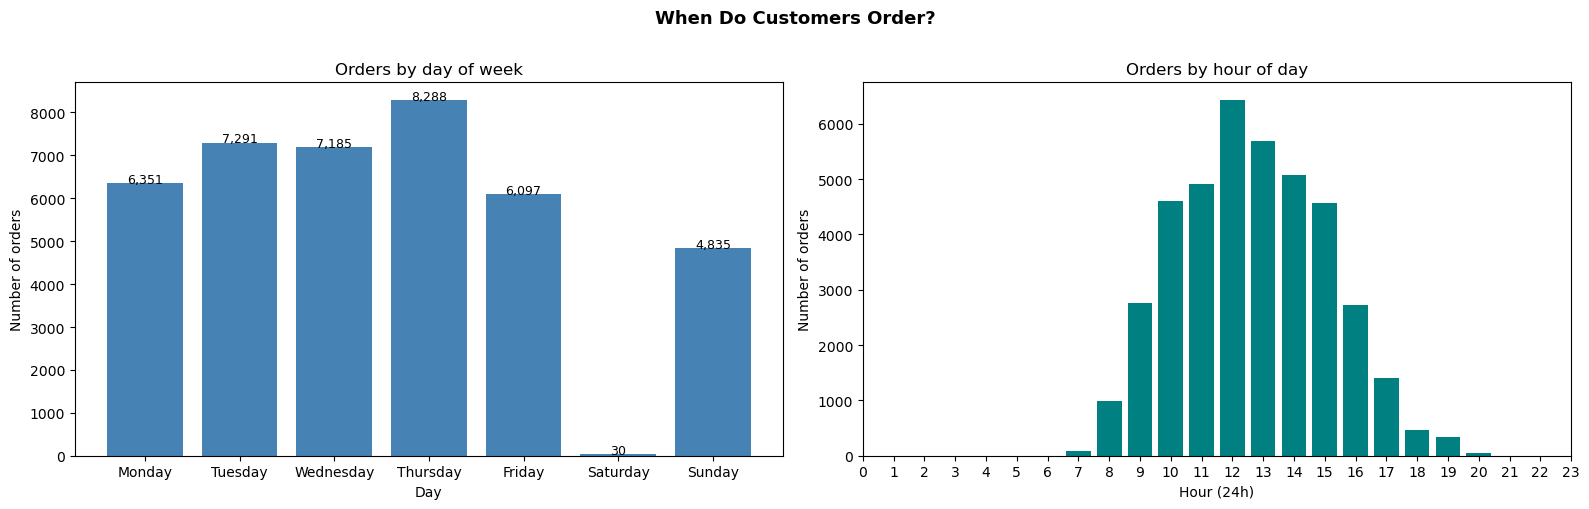


=== PEAK TRADING HOURS ===
Hour
12    6427
13    5695
14    5071
11    4903
10    4610
Name: Invoice, dtype: int64

=== ORDERS BY DAY ===
DayOfWeek
Thursday     8288
Tuesday      7291
Wednesday    7185
Monday       6351
Friday       6097
Sunday       4835
Saturday       30
Name: Invoice, dtype: int64


In [67]:
df_clean['DayOfWeek'] = df_clean['InvoiceDate'].dt.day_name()
df_clean['Hour'] = df_clean['InvoiceDate'].dt.hour

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Orders by day of week
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_counts = df_clean.groupby('DayOfWeek')['Invoice'].nunique().reindex(day_order)

axes[0].bar(day_counts.index, day_counts.values, color='steelblue', edgecolor='none')
axes[0].set_title('Orders by day of week')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Number of orders')
for i, v in enumerate(day_counts.values):
    axes[0].text(i, v + 10, f'{v:,}', ha='center', fontsize=9)

# Orders by hour
hour_counts = df_clean.groupby('Hour')['Invoice'].nunique()

axes[1].bar(hour_counts.index, hour_counts.values, color='teal', edgecolor='none')
axes[1].set_title('Orders by hour of day')
axes[1].set_xlabel('Hour (24h)')
axes[1].set_ylabel('Number of orders')
axes[1].set_xticks(range(0, 24))

plt.suptitle('When Do Customers Order?', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('time_distribution.png', bbox_inches='tight')
plt.show()

print("\n=== PEAK TRADING HOURS ===")
print(hour_counts.sort_values(ascending=False).head(5))
print("\n=== ORDERS BY DAY ===")
print(day_counts.sort_values(ascending=False))

 ## Step 6 — Patterns & Relationships

- Monthly Revenue Trend

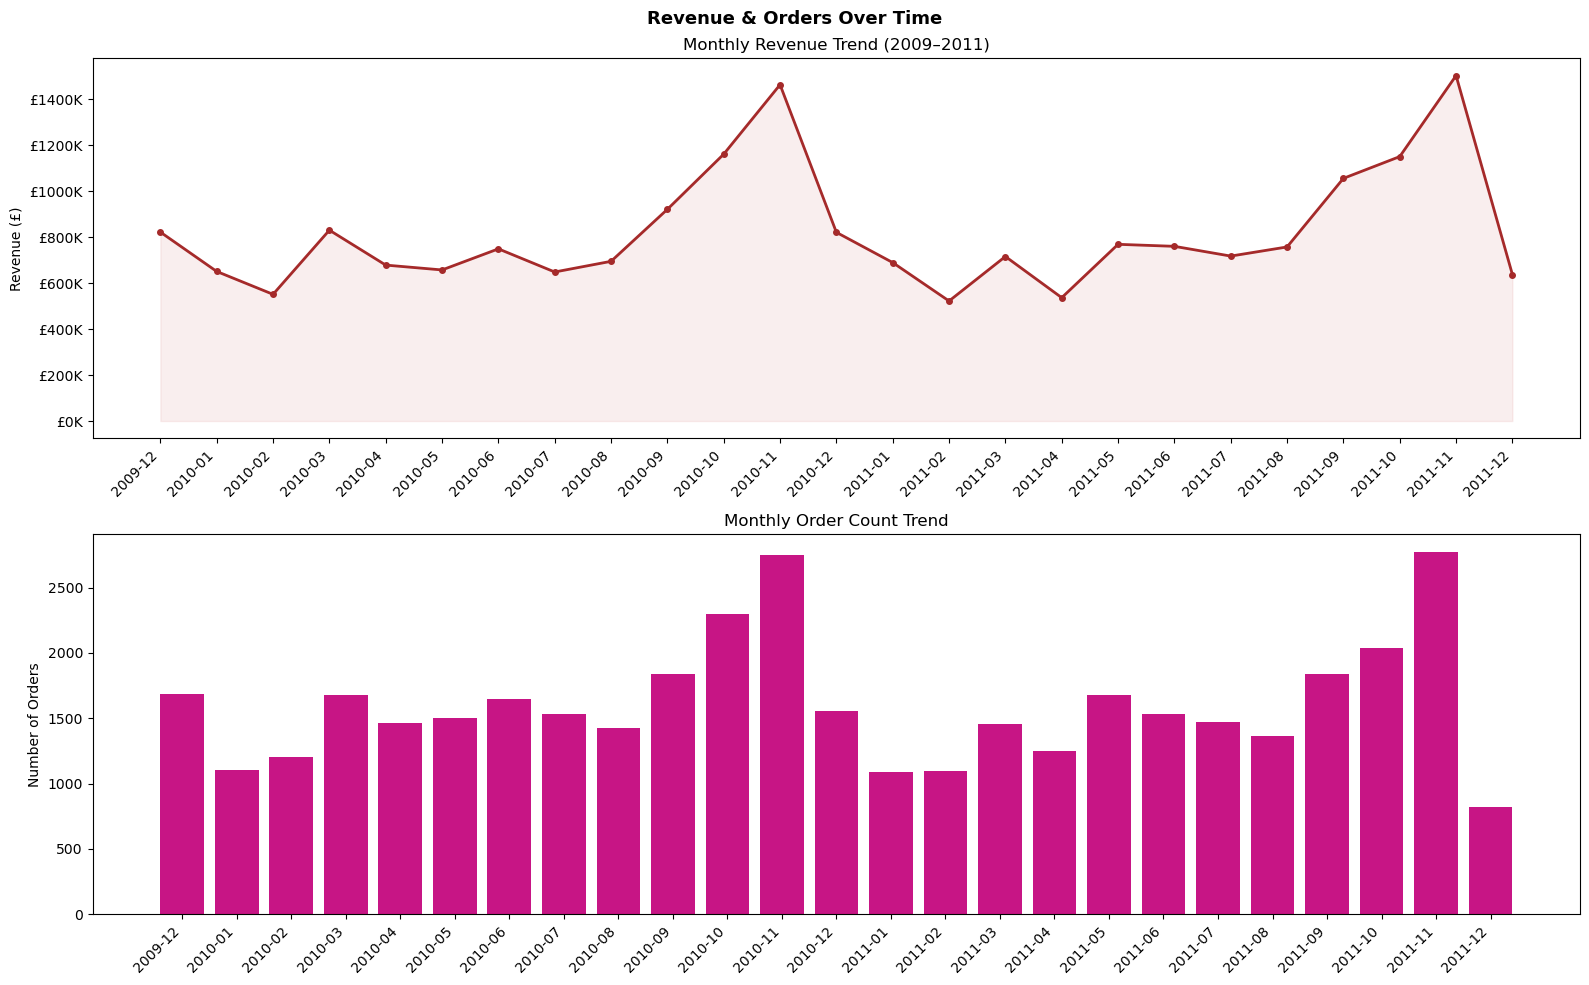

=== MONTHLY REVENUE SUMMARY ===
Best month:  2011-11 — £1,503,866.78
Worst month: 2011-02 — £522,545.56

Year 2010 total: £9,833,100.42
Year 2011 total: £9,820,676.07


In [74]:
# Extract month-year
df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M')
monthly_revenue = df_clean.groupby('YearMonth')['Revenue'].sum()
monthly_orders = df_clean.groupby('YearMonth')['Invoice'].nunique()

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Revenue trend
axes[0].plot(monthly_revenue.index.astype(str), monthly_revenue.values, 
             color='brown', linewidth=2, marker='o', markersize=4)
axes[0].fill_between(range(len(monthly_revenue)), monthly_revenue.values, 
                     alpha=0.1, color='indianred')
axes[0].set_title('Monthly Revenue Trend (2009–2011)')
axes[0].set_xlabel('')
axes[0].set_ylabel('Revenue (£)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_xticks(range(len(monthly_revenue)))
axes[0].set_xticklabels(monthly_revenue.index.astype(str), rotation=45, ha='right')

# Orders trend
axes[1].bar(range(len(monthly_orders)), monthly_orders.values, 
            color='mediumvioletred', edgecolor='none')
axes[1].set_title('Monthly Order Count Trend')
axes[1].set_xlabel('')
axes[1].set_ylabel('Number of Orders')
axes[1].set_xticks(range(len(monthly_orders)))
axes[1].set_xticklabels(monthly_orders.index.astype(str), rotation=45, ha='right')

plt.suptitle('Revenue & Orders Over Time', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('monthly_trend.png', bbox_inches='tight')
plt.show()

print("=== MONTHLY REVENUE SUMMARY ===")
print(f"Best month:  {monthly_revenue.idxmax()} — £{monthly_revenue.max():,.2f}")
print(f"Worst month: {monthly_revenue.idxmin()} — £{monthly_revenue.min():,.2f}")
print(f"\nYear 2010 total: £{df_clean[df_clean['InvoiceDate'].dt.year == 2010]['Revenue'].sum():,.2f}")
print(f"Year 2011 total: £{df_clean[df_clean['InvoiceDate'].dt.year == 2011]['Revenue'].sum():,.2f}")

- Seasonality: month of year

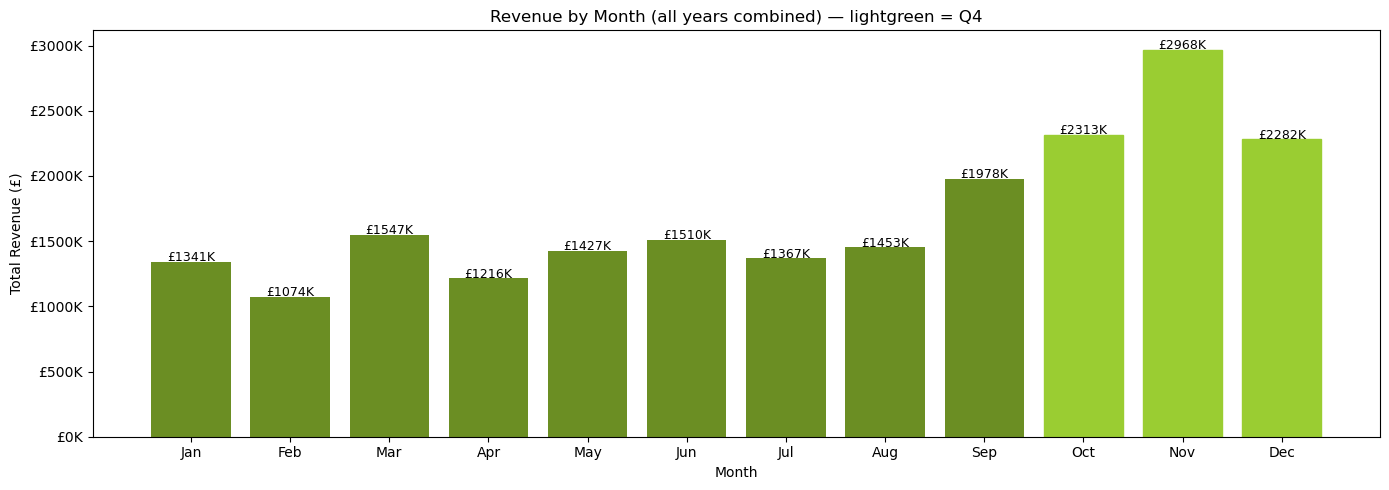

=== SEASONALITY ===
MonthName
Nov    2968159.922
Oct    2313165.950
Dec    2281745.010
Sep    1978132.183
Mar    1547130.521
Jun    1510084.320
Aug    1453093.290
May    1427002.110
Jul    1366886.391
Jan    1340966.722
Apr    1215843.743
Feb    1074050.286
Name: Revenue, dtype: float64


In [77]:
df_clean['Month'] = df_clean['InvoiceDate'].dt.month
df_clean['MonthName'] = df_clean['InvoiceDate'].dt.strftime('%b')

month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

monthly_avg = df_clean.groupby('MonthName')['Revenue'].sum().reindex(month_order)

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(monthly_avg.index, monthly_avg.values, 
              color='olivedrab', edgecolor='none')

# Highlight Q4 (Oct, Nov, Dec)
for i, month in enumerate(month_order):
    if month in ['Oct', 'Nov', 'Dec']:
        bars[i].set_color('yellowgreen')

ax.set_title('Revenue by Month (all years combined) — lightgreen = Q4')
ax.set_xlabel('Month')
ax.set_ylabel('Total Revenue (£)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
for i, v in enumerate(monthly_avg.values):
    ax.text(i, v + 5000, f'£{v/1000:.0f}K', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('seasonality.png', bbox_inches='tight')
plt.show()

print("=== SEASONALITY ===")
print(monthly_avg.sort_values(ascending=False))

- Year on year growth YOY%

In [78]:
yearly = df_clean.groupby(df_clean['InvoiceDate'].dt.year).agg(
    Revenue=('Revenue', 'sum'),
    Orders=('Invoice', 'nunique'),
    Customers=('Customer ID', 'nunique')
).reset_index()
yearly.columns = ['Year', 'Revenue', 'Orders', 'Customers']

# 2009 is only Dec so exclude from YoY — compare 2010 vs 2011
rev_2010 = yearly[yearly['Year'] == 2010]['Revenue'].values[0]
rev_2011 = yearly[yearly['Year'] == 2011]['Revenue'].values[0]
growth = (rev_2011 - rev_2010) / rev_2010 * 100

print("=== YEAR ON YEAR ===")
print(yearly.to_string(index=False))
print(f"\nRevenue growth 2010 → 2011: {growth:.1f}%")

=== YEAR ON YEAR ===
 Year     Revenue  Orders  Customers
 2009  822483.950    1682        955
 2010 9833100.424   19994       4231
 2011 9820676.074   18401       4219

Revenue growth 2010 → 2011: -0.1%


- Customer Behaviour

=== CUSTOMER LOYALTY ===
One-time buyers (1 order only):  1,623 (27.6%)
Repeat buyers (2+ orders):       4,255 (72.4%)
Loyal buyers (10+ orders):       974 (16.6%)

One-time buyer revenue:  £560,272.56 (3.2%)
Repeat buyer revenue:    £16,814,531.71 (96.8%)


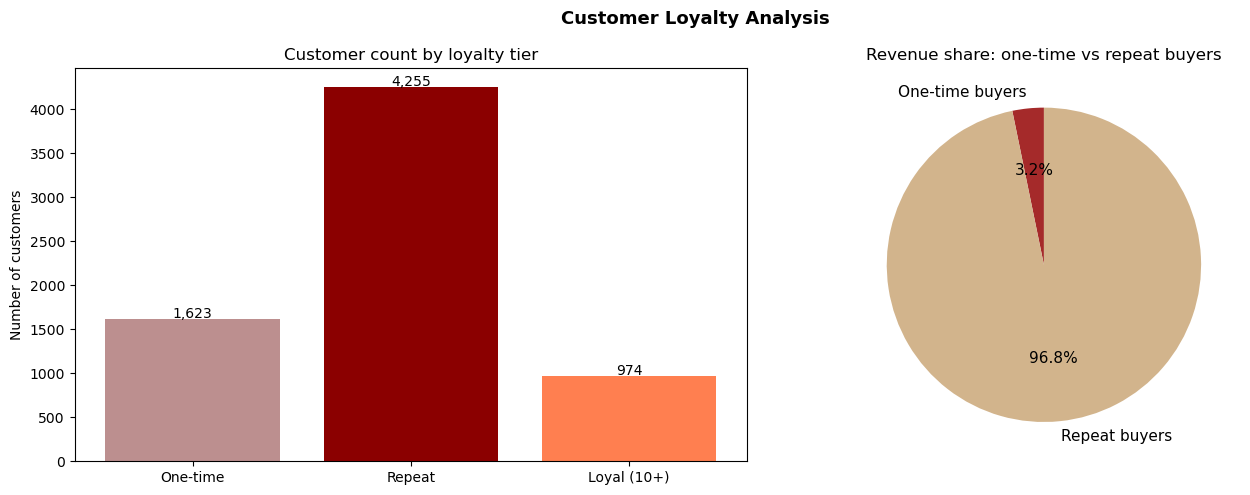

In [80]:
customer_orders = df_clean.groupby('Customer ID')['Invoice'].nunique()

one_time = (customer_orders == 1).sum()
repeat = (customer_orders > 1).sum()
loyal = (customer_orders >= 10).sum()

print("=== CUSTOMER LOYALTY ===")
print(f"One-time buyers (1 order only):  {one_time:,} ({one_time/len(customer_orders)*100:.1f}%)")
print(f"Repeat buyers (2+ orders):       {repeat:,} ({repeat/len(customer_orders)*100:.1f}%)")
print(f"Loyal buyers (10+ orders):       {loyal:,} ({loyal/len(customer_orders)*100:.1f}%)")

# Revenue split
one_time_ids = customer_orders[customer_orders == 1].index
repeat_ids = customer_orders[customer_orders > 1].index

one_time_rev = df_clean[df_clean['Customer ID'].isin(one_time_ids)]['Revenue'].sum()
repeat_rev = df_clean[df_clean['Customer ID'].isin(repeat_ids)]['Revenue'].sum()
total_rev = one_time_rev + repeat_rev

print(f"\nOne-time buyer revenue:  £{one_time_rev:,.2f} ({one_time_rev/total_rev*100:.1f}%)")
print(f"Repeat buyer revenue:    £{repeat_rev:,.2f} ({repeat_rev/total_rev*100:.1f}%)")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(['One-time', 'Repeat', 'Loyal (10+)'],
            [one_time, repeat, loyal],
            color=['rosybrown', 'darkred', 'coral'], edgecolor='none')
axes[0].set_title('Customer count by loyalty tier')
axes[0].set_ylabel('Number of customers')
for i, v in enumerate([one_time, repeat, loyal]):
    axes[0].text(i, v + 10, f'{v:,}', ha='center', fontsize=10)

axes[1].pie([one_time_rev, repeat_rev],
            labels=['One-time buyers', 'Repeat buyers'],
            colors=['brown', 'tan'],
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 11})
axes[1].set_title('Revenue share: one-time vs repeat buyers')

plt.suptitle('Customer Loyalty Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('customer_loyalty.png', bbox_inches='tight')
plt.show()

- Return Rate Analysis

=== RETURN RATE ANALYSIS ===
Total clean orders:      40,077
Cancelled/returned:      13,676
Order cancellation rate: 34.1%

Clean revenue:           £20,476,260.45
Revenue lost to returns: £1,620,726.75
Revenue return rate:     7.9%


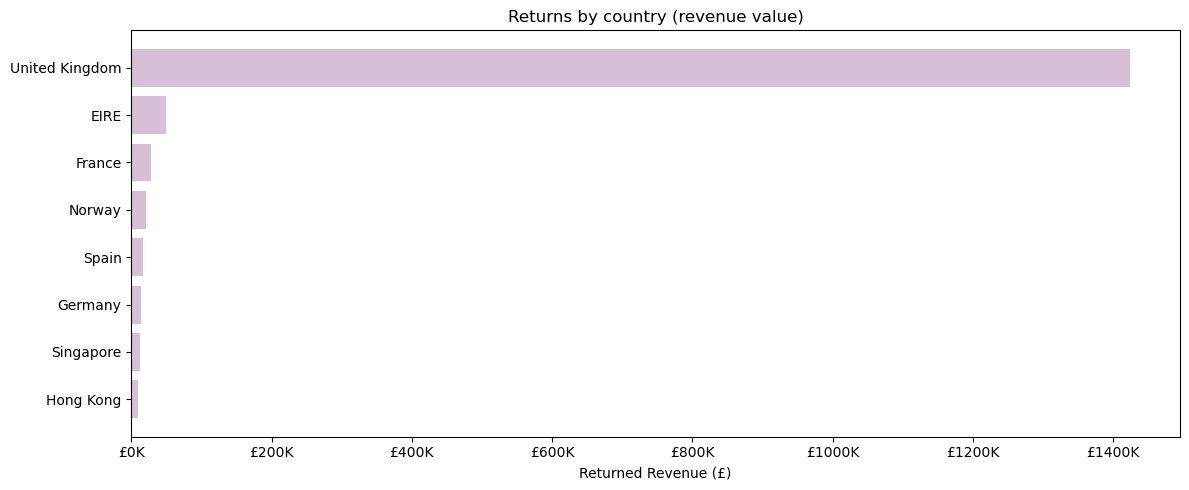

In [83]:
print("=== RETURN RATE ANALYSIS ===")
total_orders = df_clean['Invoice'].nunique()
return_orders = df_returns['Invoice'].nunique()
return_rate = return_orders / total_orders * 100

total_rev = df_clean['Revenue'].sum()
return_rev = abs(df_returns['Revenue'].sum())
revenue_return_rate = return_rev / total_rev * 100

print(f"Total clean orders:      {total_orders:,}")
print(f"Cancelled/returned:      {return_orders:,}")
print(f"Order cancellation rate: {return_rate:.1f}%")
print(f"\nClean revenue:           £{total_rev:,.2f}")
print(f"Revenue lost to returns: £{return_rev:,.2f}")
print(f"Revenue return rate:     {revenue_return_rate:.1f}%")

# Returns by country
df_returns['Country_ret'] = df_returns['Country']
returns_by_country = df_returns.groupby('Country')['Revenue'].sum().abs().sort_values(ascending=False).head(8)

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(returns_by_country.index[::-1], returns_by_country.values[::-1],
        color='thistle', edgecolor='none')
ax.set_title('Returns by country (revenue value)')
ax.set_xlabel('Returned Revenue (£)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
plt.tight_layout()
plt.savefig('returns_by_country.png', bbox_inches='tight')
plt.show()

- Correlation heatmap

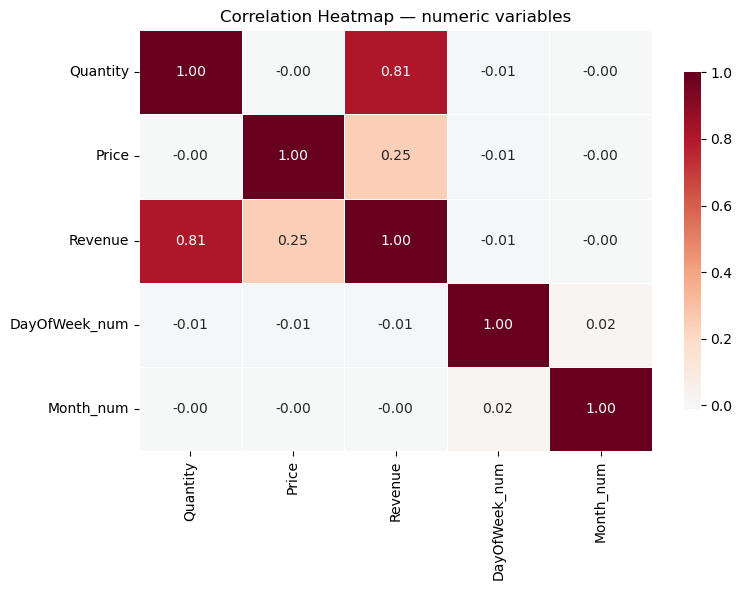

In [87]:
# Add time features
df_clean['DayOfWeek_num'] = df_clean['InvoiceDate'].dt.dayofweek
df_clean['Month_num'] = df_clean['InvoiceDate'].dt.month

corr_df = df_clean[['Quantity', 'Price', 'Revenue', 
                     'DayOfWeek_num', 'Month_num']].corr().round(2)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap — numeric variables')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

- Top customer concentration (80/20 rule)

=== 80/20 RULE ===
Total customers: 5,878
Customers making up 80% of revenue: 1,353 (23.0%)

Top 10 customers revenue:
Customer ID
18102.0    £580,987.04
14646.0    £528,602.52
14156.0    £313,437.62
14911.0    £291,420.81
17450.0    £244,784.25
13694.0    £195,640.69
17511.0    £172,132.87
16446.0    £168,472.50
16684.0    £147,142.77
12415.0    £144,458.37
Name: Revenue, dtype: object

Top 10 customers % of total revenue: 16.0%


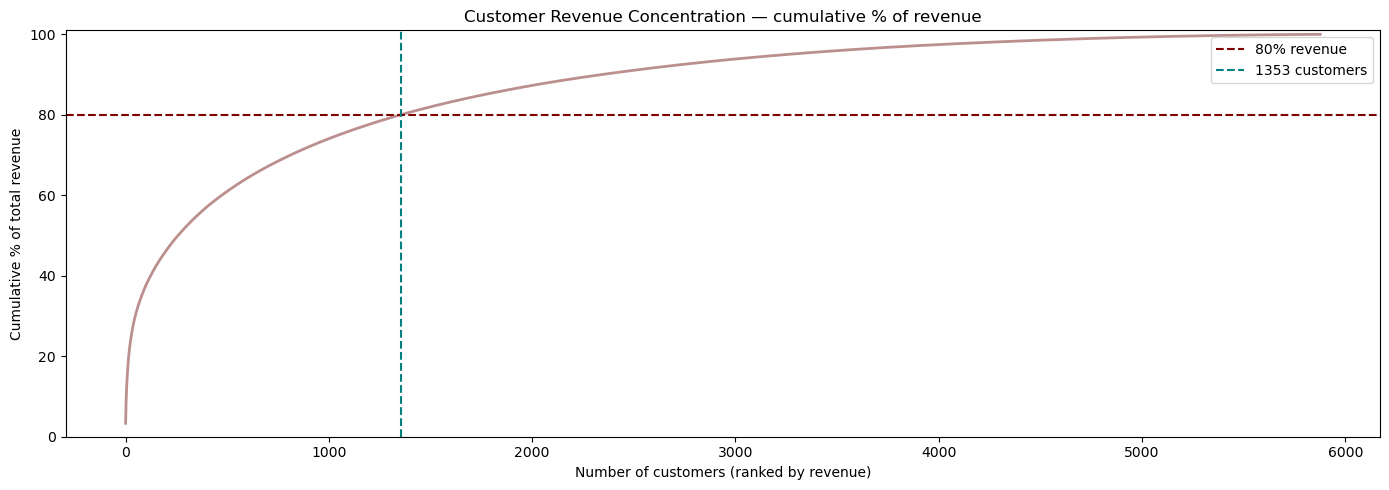

In [90]:
customer_rev = df_clean.groupby('Customer ID')['Revenue'].sum().sort_values(ascending=False)
total = customer_rev.sum()
cumulative = customer_rev.cumsum() / total * 100

# How many customers = 80% of revenue?
customers_80 = (cumulative <= 80).sum()
pct_customers = customers_80 / len(customer_rev) * 100

print("=== 80/20 RULE ===")
print(f"Total customers: {len(customer_rev):,}")
print(f"Customers making up 80% of revenue: {customers_80:,} ({pct_customers:.1f}%)")
print(f"\nTop 10 customers revenue:")
print(customer_rev.head(10).apply(lambda x: f'£{x:,.2f}'))
print(f"\nTop 10 customers % of total revenue: {customer_rev.head(10).sum()/total*100:.1f}%")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(range(len(cumulative)), cumulative.values, color='rosybrown', linewidth=2)
ax.axhline(y=80, color='maroon', linestyle='--', linewidth=1.5, label='80% revenue')
ax.axvline(x=customers_80, color='teal', linestyle='--', linewidth=1.5, 
           label=f'{customers_80} customers')
ax.set_title('Customer Revenue Concentration — cumulative % of revenue')
ax.set_xlabel('Number of customers (ranked by revenue)')
ax.set_ylabel('Cumulative % of total revenue')
ax.legend()
ax.set_ylim(0, 101)
plt.tight_layout()
plt.savefig('customer_concentration.png', bbox_inches='tight')
plt.show()

** Analysis Done. **

Downloading CSVs for Dashboard

In [93]:
df_clean.to_csv('clean_sales.csv', index=False)
df_returns.to_csv('returns.csv', index=False)

monthly = df_clean.groupby('YearMonth').agg(
    Revenue=('Revenue','sum'),
    Orders=('Invoice','nunique')
).reset_index()
monthly['YearMonth'] = monthly['YearMonth'].astype(str)
monthly.to_csv('monthly_summary.csv', index=False)

customer_summary = df_clean.groupby('Customer ID').agg(
    Revenue=('Revenue','sum'),
    Orders=('Invoice','nunique')
).reset_index()
customer_summary.to_csv('customer_summary.csv', index=False)

country_summary = df_clean.groupby('Country')['Revenue'].sum().reset_index()
country_summary.to_csv('country_summary.csv', index=False)

print("All CSVs exported.")

All CSVs exported.
